In [58]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [59]:
bank_loan_approval_dataset = pd.read_csv(
    csv_path if "csv_path" in globals() else "feed/bank_loan_approval_dataset.csv"
)

bank_loan_approval_dataset.head()

,application_id,first_name,last_name,age,employment_type,employment_years,annual_income,credit_score,debt_to_income_ratio,savings_balance,existing_loans_count,missed_payments_12m,home_ownership,loan_purpose,loan_term_months,interest_rate,requested_loan_amount,loan_approved,loan_approved decision,approved_loan_amount
0,APP00001,Aarav0001,Adams0001,25,Salaried,0,42963.81,672,0.169,35540.30,0,0,Rent,Business,24,13.65,10901.07,0,No,0.00
1,APP00002,Aiden0002,Baker0002,55,Salaried,27,90949.60,643,0.313,9760.72,3,0,Rent,Business,48,14.35,24216.29,1,Yes,16041.35
2,APP00003,Amara0003,Brooks0003,50,Salaried,24,60941.84,748,0.476,53373.76,2,0,Mortgage,Personal,72,13.05,29579.03,1,Yes,19484.45
3,APP00004,Bella0004,Carter0004,40,Salaried,11,52830.38,660,0.115,17127.76,0,0,Rent,Education,12,12.48,28667.75,0,No,0.00
4,APP00005,Caleb0005,Coleman0005,40,Business Owner,18,57200.50,654,0.465,32561.08,2,0,Rent,Medical,12,14.00,27119.93,1,Yes,15375.22


In [60]:
bank_loan_approval_dataset2 =  bank_loan_approval_dataset.copy()
bank_loan_approval_dataset2.shape,bank_loan_approval_dataset.shape



((1000, 20), (1000, 20))

#### Creating dataframes with numeric and non numeric columns 

In [61]:
numeric_cols = bank_loan_approval_dataset2[[
    "employment_years",
    "annual_income",
    "credit_score",
    "debt_to_income_ratio",
    "savings_balance",
    "existing_loans_count",
    "missed_payments_12m",
    "requested_loan_amount",
    "age",
]]

In [62]:
non_numeric_cols = bank_loan_approval_dataset2[[
    "employment_years",
    "annual_income",
    "credit_score",
    "debt_to_income_ratio",
    "savings_balance",
    "existing_loans_count",
    "missed_payments_12m",
    "requested_loan_amount",
    "age",
    "home_ownership",
    "loan_purpose",
]]

In [63]:
# non_numeric_cols.head()

In [64]:
numeric_cols.head()

,employment_years,annual_income,credit_score,debt_to_income_ratio,savings_balance,existing_loans_count,missed_payments_12m,requested_loan_amount,age
0,0,42963.81,672,0.169,35540.30,0,0,10901.07,25
1,27,90949.60,643,0.313,9760.72,3,0,24216.29,55
2,24,60941.84,748,0.476,53373.76,2,0,29579.03,50
3,11,52830.38,660,0.115,17127.76,0,0,28667.75,40
4,18,57200.50,654,0.465,32561.08,2,0,27119.93,40


In [65]:
target = bank_loan_approval_dataset2[[
    "requested_loan_amount"
]]

In [66]:
target.head()

,requested_loan_amount
0,10901.07
1,24216.29
2,29579.03
3,28667.75
4,27119.93


In [67]:
numeric_cols.head()

,employment_years,annual_income,credit_score,debt_to_income_ratio,savings_balance,existing_loans_count,missed_payments_12m,requested_loan_amount,age
0,0,42963.81,672,0.169,35540.30,0,0,10901.07,25
1,27,90949.60,643,0.313,9760.72,3,0,24216.29,55
2,24,60941.84,748,0.476,53373.76,2,0,29579.03,50
3,11,52830.38,660,0.115,17127.76,0,0,28667.75,40
4,18,57200.50,654,0.465,32561.08,2,0,27119.93,40


#### Creating a best fit line for the non numeric dataframe

Best-fit equation:
requested_loan_amount = (0.438001) * annual_income + (-599.061121)


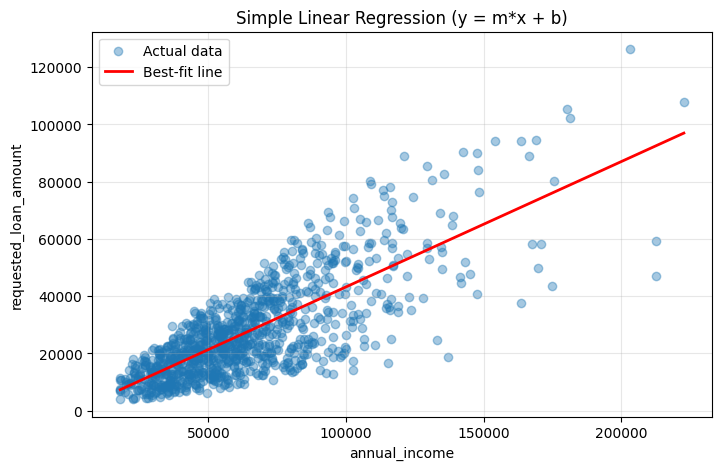

In [68]:
import matplotlib.pyplot as plt

# Simple y = m*x + b using one numeric feature
feature = "annual_income"
x_simple = numeric_cols[[feature]]   # x
y_simple = y                         # y (already available in notebook)

# Fit simple linear regression
simple_model = LinearRegression()
simple_model.fit(x_simple, y_simple)

m = simple_model.coef_[0]
b = simple_model.intercept_

print(f"Best-fit equation:\nrequested_loan_amount = ({m:.6f}) * {feature} + ({b:.6f})")

# Plot data points + best-fit line
x_vals = x_simple[feature].values
y_pred_simple = simple_model.predict(x_simple)

order = np.argsort(x_vals)
plt.figure(figsize=(8, 5))
plt.scatter(x_vals, y_simple, alpha=0.4, label="Actual data")
plt.plot(x_vals[order], y_pred_simple[order], color="red", linewidth=2, label="Best-fit line")
plt.xlabel(feature)
plt.ylabel("requested_loan_amount")
plt.title("Simple Linear Regression (y = m*x + b)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Implementing y=mx+ b for the numeric dataframe

In [69]:
# Best-fit line equation explanation
print("=" * 60)
print("Simple Linear Regression: Best-Fit Line Equation")
print("=" * 60)
print()
print("Formula:  y = m*x + b")
print()
print("Where:")
print(f"  y  = requested_loan_amount (target / dependent variable)")
print(f"  x  = annual_income         (feature / independent variable)")
print(f"  m  = {m:.6f}             (slope)")
print(f"  b  = {b:.6f}          (intercept)")
print()
print("So the equation is:")
print(f"  requested_loan_amount = ({m:.6f}) * annual_income + ({b:.6f})")
print()
print("How m and b were calculated:")
print("-" * 60)
print("  m (slope)     = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / Σ[(xᵢ - x̄)²]")
print("  b (intercept) = ȳ - m * x̄")
print()

x_mean = x_simple["annual_income"].mean()
y_mean = y_simple.mean()

print(f"  x̄ (mean of annual_income)           = {x_mean:,.2f}")
print(f"  ȳ (mean of requested_loan_amount)   = {y_mean:,.2f}")
print()
print(f"  b = ȳ - m * x̄")
print(f"  b = {y_mean:.2f} - ({m:.6f} * {x_mean:.2f})")
print(f"  b = {b:.6f}")
print()
print("Interpretation:")
print(f"  For every $1 increase in annual_income,")
print(f"  the requested_loan_amount increases by ${m:.6f}")
print(f"  When annual_income = 0, predicted loan amount = ${b:.2f}")

Simple Linear Regression: Best-Fit Line Equation

Formula:  y = m*x + b

Where:
  y  = requested_loan_amount (target / dependent variable)
  x  = annual_income         (feature / independent variable)
  m  = 0.438001             (slope)
  b  = -599.061121          (intercept)

So the equation is:
  requested_loan_amount = (0.438001) * annual_income + (-599.061121)

How m and b were calculated:
------------------------------------------------------------
  m (slope)     = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / Σ[(xᵢ - x̄)²]
  b (intercept) = ȳ - m * x̄

  x̄ (mean of annual_income)           = 64,227.46
  ȳ (mean of requested_loan_amount)   = 27,532.64

  b = ȳ - m * x̄
  b = 27532.64 - (0.438001 * 64227.46)
  b = -599.061121

Interpretation:
  For every $1 increase in annual_income,
  the requested_loan_amount increases by $0.438001
  When annual_income = 0, predicted loan amount = $-599.06


#### Implementing y = mx + b for the numeric dataframe (Using Multiple features)

Multiple Linear Regression Equation

  y = b + m1*x1 + m2*x2 + ... + mn*xn

Where:
  y  = requested_loan_amount  (what we want to predict)

  x1 = employment_years                m1 = +255.309963
  x2 = annual_income                   m2 = +0.433886
  x3 = credit_score                    m3 = +0.386337
  x4 = debt_to_income_ratio            m4 = -19785.481197
  x5 = savings_balance                 m5 = +0.008784
  x6 = existing_loans_count            m6 = +30.522848
  x7 = missed_payments_12m             m7 = +362.267907
  x8 = age                             m8 = -255.813725

  b (intercept) = 10883.0513

Full equation:
  requested_loan_amount = 10883.0513 (+255.3100)*employment_years + (+0.4339)*annual_income + (+0.3863)*credit_score + (-19785.4812)*debt_to_income_ratio + (+0.0088)*savings_balance + (+30.5228)*existing_loans_count + (+362.2679)*missed_payments_12m + (-255.8137)*age

-----------------------------------------------------------------
How the coefficients (m) are calcula

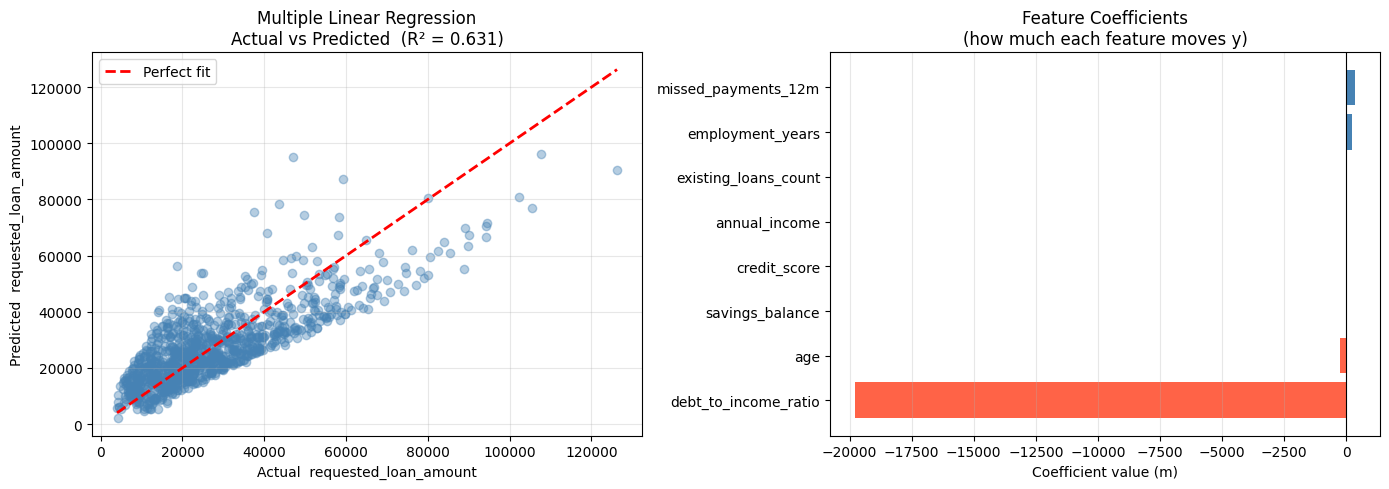

In [70]:
from sklearn.metrics import r2_score

# ── Multiple Linear Regression: y = b + m1*x1 + m2*x2 + ... + mn*xn ──

# Features (drop target from predictors)
X_multi = numeric_cols.drop(columns=["requested_loan_amount"])
y_multi  = target["requested_loan_amount"]

# Fit model
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)
y_pred_multi = multi_model.predict(X_multi)

# ── Print the equation ──
print("=" * 65)
print("Multiple Linear Regression Equation")
print("=" * 65)
print()
print("  y = b + m1*x1 + m2*x2 + ... + mn*xn")
print()
print("Where:")
print(f"  y  = requested_loan_amount  (what we want to predict)\n")

coef_df = pd.DataFrame({
    "Variable": X_multi.columns,
    "Coefficient (m)": multi_model.coef_
})
for i, row in coef_df.iterrows():
    print(f"  x{i+1} = {row['Variable']:<30}  m{i+1} = {row['Coefficient (m)']:+.6f}")

print(f"\n  b (intercept) = {multi_model.intercept_:.4f}")
print()

# Build the full equation string
terms = " + ".join(
    f"({m:+.4f})*{feat}"
    for feat, m in zip(X_multi.columns, multi_model.coef_)
)
print("Full equation:")
print(f"  requested_loan_amount = {multi_model.intercept_:.4f} {terms}")
print()

# ── How m values are calculated (matrix form) ──
print("-" * 65)
print("How the coefficients (m) are calculated:")
print()
print("  In matrix form:  m = (XᵀX)⁻¹ Xᵀy")
print()
print("  Step-by-step:")
print("  1. Stack all features into matrix X  (shape: n_samples × n_features)")
print("  2. Multiply Xᵀ · X  → square matrix")
print("  3. Take its inverse  (XᵀX)⁻¹")
print("  4. Multiply by Xᵀ · y  → gives all m coefficients at once")
print()
print("  The intercept b is then:  b = ȳ - m1*x̄1 - m2*x̄2 - ... - mn*x̄n")
print()

# Show means used for intercept
for feat in X_multi.columns:
    print(f"  x̄ ({feat:<30}) = {X_multi[feat].mean():>10,.2f}")
print(f"  ȳ (requested_loan_amount)          = {y_multi.mean():>10,.2f}")

# ── Actual vs Predicted plot ──
r2 = r2_score(y_multi, y_pred_multi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_multi, y_pred_multi, alpha=0.4, color="steelblue")
lims = [y_multi.min(), y_multi.max()]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
axes[0].set_xlabel("Actual  requested_loan_amount")
axes[0].set_ylabel("Predicted  requested_loan_amount")
axes[0].set_title(f"Multiple Linear Regression\nActual vs Predicted  (R² = {r2:.3f})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Coefficient bar chart
coef_df_sorted = coef_df.sort_values("Coefficient (m)")
colors = ["tomato" if v < 0 else "steelblue" for v in coef_df_sorted["Coefficient (m)"]]
axes[1].barh(coef_df_sorted["Variable"], coef_df_sorted["Coefficient (m)"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Coefficient value (m)")
axes[1].set_title("Feature Coefficients\n(how much each feature moves y)")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

#### Explaining Gradient Decent based on the cost function, (minimal cost function)

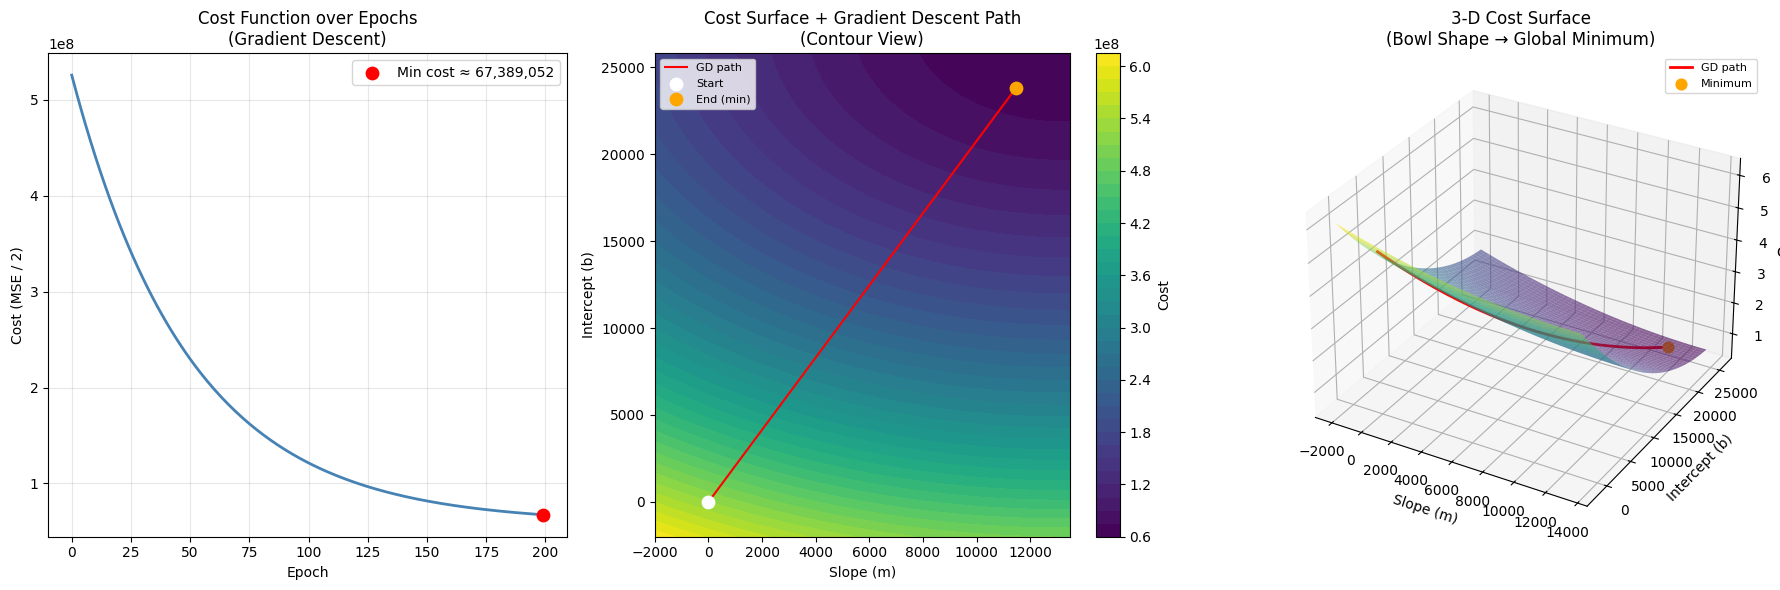

Gradient Descent Summary
  Learning rate      : 0.01
  Epochs             : 200
  Final slope  (m)   : 11,483.9906
  Final intercept (b): 23,843.8256
  Final cost (MSE/2) : 67,389,052.0419
  Min cost reached @ epoch 199

Update rules used:
  m  ←  m  -  α · (1/n) · Σ[(ŷᵢ - yᵢ) · xᵢ]
  b  ←  b  -  α · (1/n) · Σ[(ŷᵢ - yᵢ)    ]


In [71]:
# Gradient Descent Visualization - Cost Function Minimization
# Using simple linear regression (annual_income -> requested_loan_amount)

# ── Setup ──
x = x_simple["annual_income"].values
y_vals = y_simple.values

x_norm = (x - x.mean()) / x.std()   # normalize for stable gradient descent

# ── Gradient Descent ──
np.random.seed(42)
m_gd = 0.0          # slope
b_gd = 0.0          # intercept
lr    = 0.01        # learning rate
n     = len(x_norm)
epochs = 200

cost_history = []
m_history    = []
b_history    = []

for epoch in range(epochs):
    y_pred_gd = m_gd * x_norm + b_gd
    residuals = y_pred_gd - y_vals

    # Cost = MSE
    cost = (1 / (2 * n)) * np.sum(residuals ** 2)
    cost_history.append(cost)
    m_history.append(m_gd)
    b_history.append(b_gd)

    # Gradients
    dm = (1 / n) * np.sum(residuals * x_norm)
    db = (1 / n) * np.sum(residuals)

    # Update parameters
    m_gd -= lr * dm
    b_gd -= lr * db

# ── Grid for cost surface ──
m_range = np.linspace(min(m_history) - 2000, max(m_history) + 2000, 200)
b_range = np.linspace(min(b_history) - 2000, max(b_history) + 2000, 200)
M, B = np.meshgrid(m_range, b_range)

# Compute MSE over grid
Z = np.array([
    (1 / (2 * n)) * np.sum((mi * x_norm + bi - y_vals) ** 2)
    for mi, bi in zip(M.ravel(), B.ravel())
]).reshape(M.shape)

# ── Plot ──
fig = plt.figure(figsize=(18, 6))

# ---------- Plot 1: Cost vs Epoch ----------
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(epochs), cost_history, color="steelblue", linewidth=2)
ax1.scatter([np.argmin(cost_history)], [min(cost_history)],
            color="red", zorder=5, s=80, label=f"Min cost ≈ {min(cost_history):,.0f}")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cost (MSE / 2)")
ax1.set_title("Cost Function over Epochs\n(Gradient Descent)")
ax1.legend()
ax1.grid(alpha=0.3)

# ---------- Plot 2: Cost Surface (contour) + path ----------
ax2 = fig.add_subplot(1, 3, 2)
cp = ax2.contourf(M, B, Z, levels=50, cmap="viridis")
fig.colorbar(cp, ax=ax2, label="Cost")
ax2.plot(m_history, b_history, color="red", linewidth=1.5, label="GD path")
ax2.scatter(m_history[0],  b_history[0],  color="white",  s=80, zorder=5, label="Start")
ax2.scatter(m_history[-1], b_history[-1], color="orange", s=80, zorder=5, label="End (min)")
ax2.set_xlabel("Slope (m)")
ax2.set_ylabel("Intercept (b)")
ax2.set_title("Cost Surface + Gradient Descent Path\n(Contour View)")
ax2.legend(fontsize=8)

# ---------- Plot 3: 3-D cost surface ----------
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
ax3.plot_surface(M, B, Z, cmap="viridis", alpha=0.6, linewidth=0)
ax3.plot(m_history, b_history, cost_history, color="red", linewidth=2, label="GD path")
ax3.scatter([m_history[-1]], [b_history[-1]], [min(cost_history)],
            color="orange", s=60, zorder=5, label="Minimum")
ax3.set_xlabel("Slope (m)")
ax3.set_ylabel("Intercept (b)")
ax3.set_zlabel("Cost")
ax3.set_title("3-D Cost Surface\n(Bowl Shape → Global Minimum)")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("=" * 55)
print("Gradient Descent Summary")
print("=" * 55)
print(f"  Learning rate      : {lr}")
print(f"  Epochs             : {epochs}")
print(f"  Final slope  (m)   : {m_gd:,.4f}")
print(f"  Final intercept (b): {b_gd:,.4f}")
print(f"  Final cost (MSE/2) : {cost_history[-1]:,.4f}")
print(f"  Min cost reached @ epoch {np.argmin(cost_history)}")
print()
print("Update rules used:")
print("  m  ←  m  -  α · (1/n) · Σ[(ŷᵢ - yᵢ) · xᵢ]")
print("  b  ←  b  -  α · (1/n) · Σ[(ŷᵢ - yᵢ)    ]")

#### Training the model based on the minumal cost function dereived from gradient decent

Multiple Linear Regression trained with Gradient Descent

Formula:  y = b + m1*x1 + m2*x2 + ... + mn*xn

  x1 = employment_years                m1 = +26.159969
  x2 = annual_income                   m2 = +0.404963
  x3 = credit_score                    m3 = -0.222403
  x4 = debt_to_income_ratio            m4 = -19898.862622
  x5 = savings_balance                 m5 = +0.037216
  x6 = existing_loans_count            m6 = -7.822015
  x7 = missed_payments_12m             m7 = +375.063923
  x8 = age                             m8 = -30.569960

  b (intercept) = 6335.5550

Full equation:
  requested_loan_amount = 6335.5550 (+26.1600)*employment_years (+0.4050)*annual_income (-0.2224)*credit_score (-19898.8626)*debt_to_income_ratio (+0.0372)*savings_balance (-7.8220)*existing_loans_count (+375.0639)*missed_payments_12m (-30.5700)*age

  R²    : 0.6279
  Epochs: 500  |  Learning rate: 0.01
  Final cost (MSE/2): 54,607,963.3832
  Min   cost (MSE/2): 54,607,963.3832  @ epoch 499


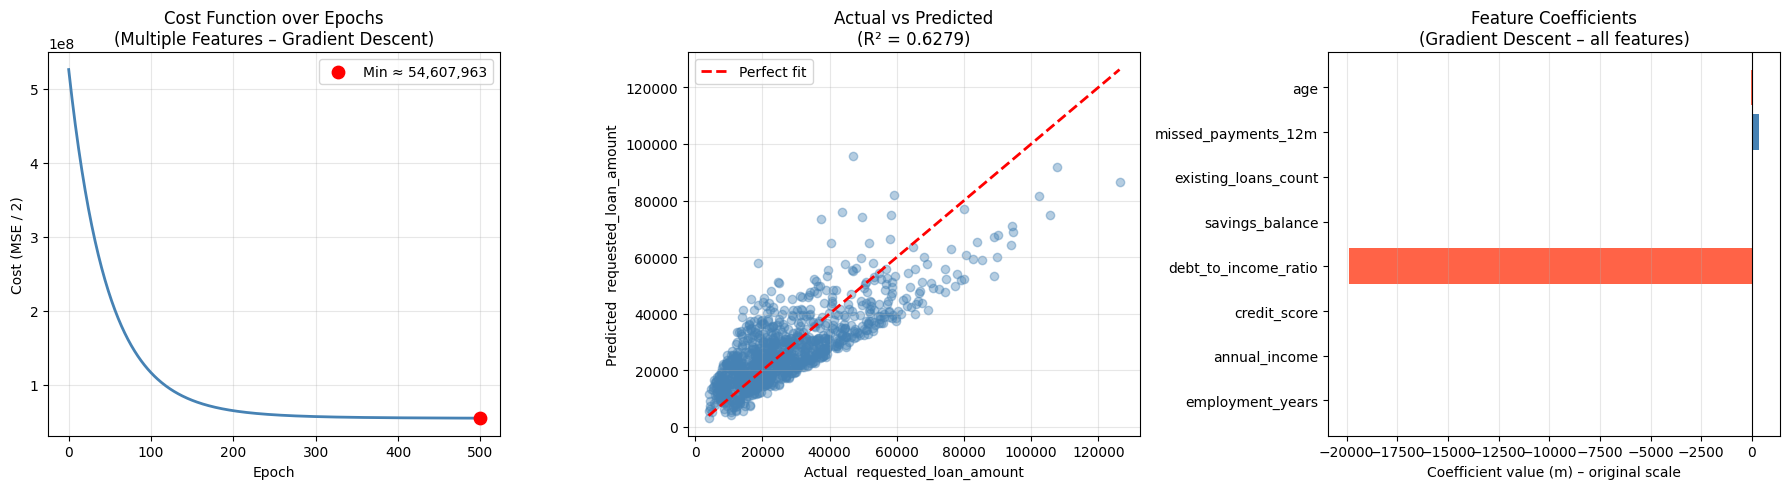

In [72]:
# Multiple Linear Regression trained with Gradient Descent (all features)
# y = b + m1*x1 + m2*x2 + ... + mn*xn

# ── Prepare data ──
X_all = numeric_cols.drop(columns=["requested_loan_amount"]).values   # shape: (n, p)
y_all = target["requested_loan_amount"].values                        # shape: (n,)

feature_names = numeric_cols.drop(columns=["requested_loan_amount"]).columns.tolist()

n_samples, n_features = X_all.shape

# ── Normalize features (zero mean, unit std) for stable gradient descent ──
X_mean = X_all.mean(axis=0)
X_std  = X_all.std(axis=0)
X_norm = (X_all - X_mean) / X_std

# ── Initialize parameters ──
np.random.seed(42)
m_vec = np.zeros(n_features)   # one slope per feature
b_gd_multi  = 0.0

learning_rate = 0.01
n_epochs      = 500

cost_history_multi = []

# ── Gradient Descent loop ──
for epoch in range(n_epochs):
    y_pred_gd_multi = X_norm @ m_vec + b_gd_multi          # (n,)
    residuals       = y_pred_gd_multi - y_all               # (n,)

    cost = (1 / (2 * n_samples)) * np.sum(residuals ** 2)
    cost_history_multi.append(cost)

    # Gradients
    dm = (1 / n_samples) * (X_norm.T @ residuals)          # (p,)
    db = (1 / n_samples) * np.sum(residuals)

    # Update
    m_vec    -= learning_rate * dm
    b_gd_multi -= learning_rate * db

# ── Convert coefficients back to original feature scale ──
m_original = m_vec / X_std
b_original = b_gd_multi - np.sum(m_vec * X_mean / X_std)

# ── Final predictions ──
y_pred_final = X_all @ m_original + b_original

# ── R² score ──
ss_res = np.sum((y_all - y_pred_final) ** 2)
ss_tot = np.sum((y_all - y_all.mean()) ** 2)
r2_gd  = 1 - ss_res / ss_tot

# ── Print equation ──
print("=" * 70)
print("Multiple Linear Regression trained with Gradient Descent")
print("=" * 70)
print()
print("Formula:  y = b + m1*x1 + m2*x2 + ... + mn*xn\n")
for i, (feat, coef) in enumerate(zip(feature_names, m_original)):
    print(f"  x{i+1} = {feat:<30}  m{i+1} = {coef:+.6f}")
print(f"\n  b (intercept) = {b_original:.4f}")
print()
terms = " ".join(f"({c:+.4f})*{f}" for f, c in zip(feature_names, m_original))
print("Full equation:")
print(f"  requested_loan_amount = {b_original:.4f} {terms}")
print()
print(f"  R²    : {r2_gd:.4f}")
print(f"  Epochs: {n_epochs}  |  Learning rate: {learning_rate}")
print(f"  Final cost (MSE/2): {cost_history_multi[-1]:,.4f}")
print(f"  Min   cost (MSE/2): {min(cost_history_multi):,.4f}  @ epoch {np.argmin(cost_history_multi)}")

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Cost over epochs
axes[0].plot(cost_history_multi, color="steelblue", linewidth=2)
axes[0].scatter([np.argmin(cost_history_multi)], [min(cost_history_multi)],
                color="red", zorder=5, s=80, label=f"Min ≈ {min(cost_history_multi):,.0f}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cost (MSE / 2)")
axes[0].set_title("Cost Function over Epochs\n(Multiple Features – Gradient Descent)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2) Actual vs Predicted
axes[1].scatter(y_all, y_pred_final, alpha=0.4, color="steelblue")
lims = [y_all.min(), y_all.max()]
axes[1].plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
axes[1].set_xlabel("Actual  requested_loan_amount")
axes[1].set_ylabel("Predicted  requested_loan_amount")
axes[1].set_title(f"Actual vs Predicted\n(R² = {r2_gd:.4f})")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3) Coefficient bar chart (original scale)
colors = ["tomato" if c < 0 else "steelblue" for c in m_original]
axes[2].barh(feature_names, m_original, color=colors)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("Coefficient value (m) – original scale")
axes[2].set_title("Feature Coefficients\n(Gradient Descent – all features)")
axes[2].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

exporting the non numeric dataframe for another model training

In [73]:

%store numeric_cols
%store target
%store non_numeric_cols

Stored 'numeric_cols' (DataFrame)
Stored 'target' (DataFrame)
Stored 'non_numeric_cols' (DataFrame)


In [74]:
end

NameError: name 'end' is not defined

In [ ]:
end

NameError: name 'end' is not defined